In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/bank_edfb3307c0ac501be2763af887661ec9.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,30,1787,19,79,1,-1,0,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,33,4789,11,220,1,339,4,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,35,1350,16,185,1,330,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,199,4,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,59,0,5,226,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
x = df_encoded.drop('y_yes', axis=1)
y = df_encoded['y_yes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)

y_dummy = dummy.predict(x_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_dummy))
print("Dummy")

Dummy Accuracy: 0.8850828729281768
Dummy


In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)

y_pred = tree.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))

Accuracy: 0.8486187845303867
precision: 0.3700787401574803
recall: 0.4519230769230769
f1: 0.4069264069264069


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.90      0.91       801
        True       0.37      0.45      0.41       104

    accuracy                           0.85       905
   macro avg       0.65      0.68      0.66       905
weighted avg       0.86      0.85      0.86       905



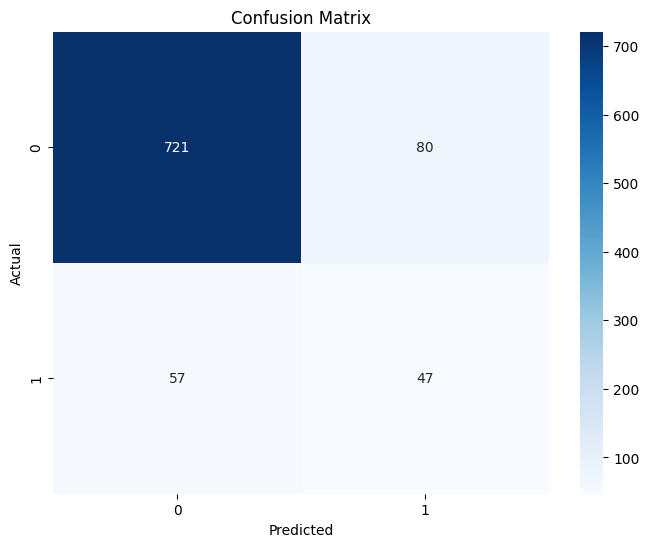

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

depths = range(1, 21)
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, x_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

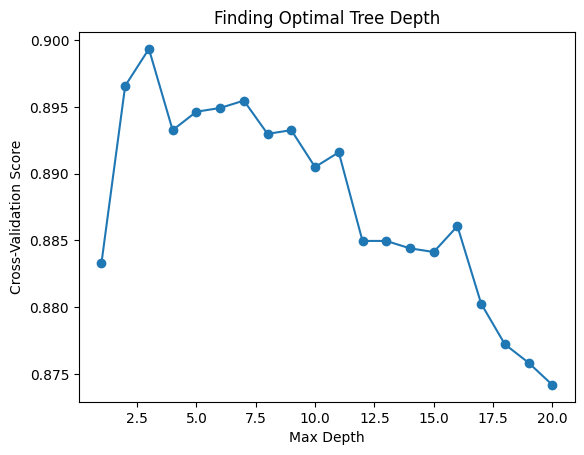

In [ ]:
plt.figure()
plt.plot(depths, cv_scores, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Cross-Validation Score')
plt.title('Finding Optimal Tree Depth')
plt.show()

In [ ]:
# Find the best depth based on cv_scores
best_depth_index = cv_scores.index(max(cv_scores))
best_depth = depths[best_depth_index]

best_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    random_state=42
)

best_tree.fit(x_train, y_train)

y_train_pred = best_tree.predict(x_train)
y_test_pred = best_tree.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


#recall (positive Class)
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))

Train Accuracy: 0.7419800884955752
Test Accuracy: 0.7237569060773481
Train Recall: 0.8729016786570744
Test Recall: 0.8461538461538461
Train Precision: 0.29260450160771706
Test Precision: 0.2732919254658385


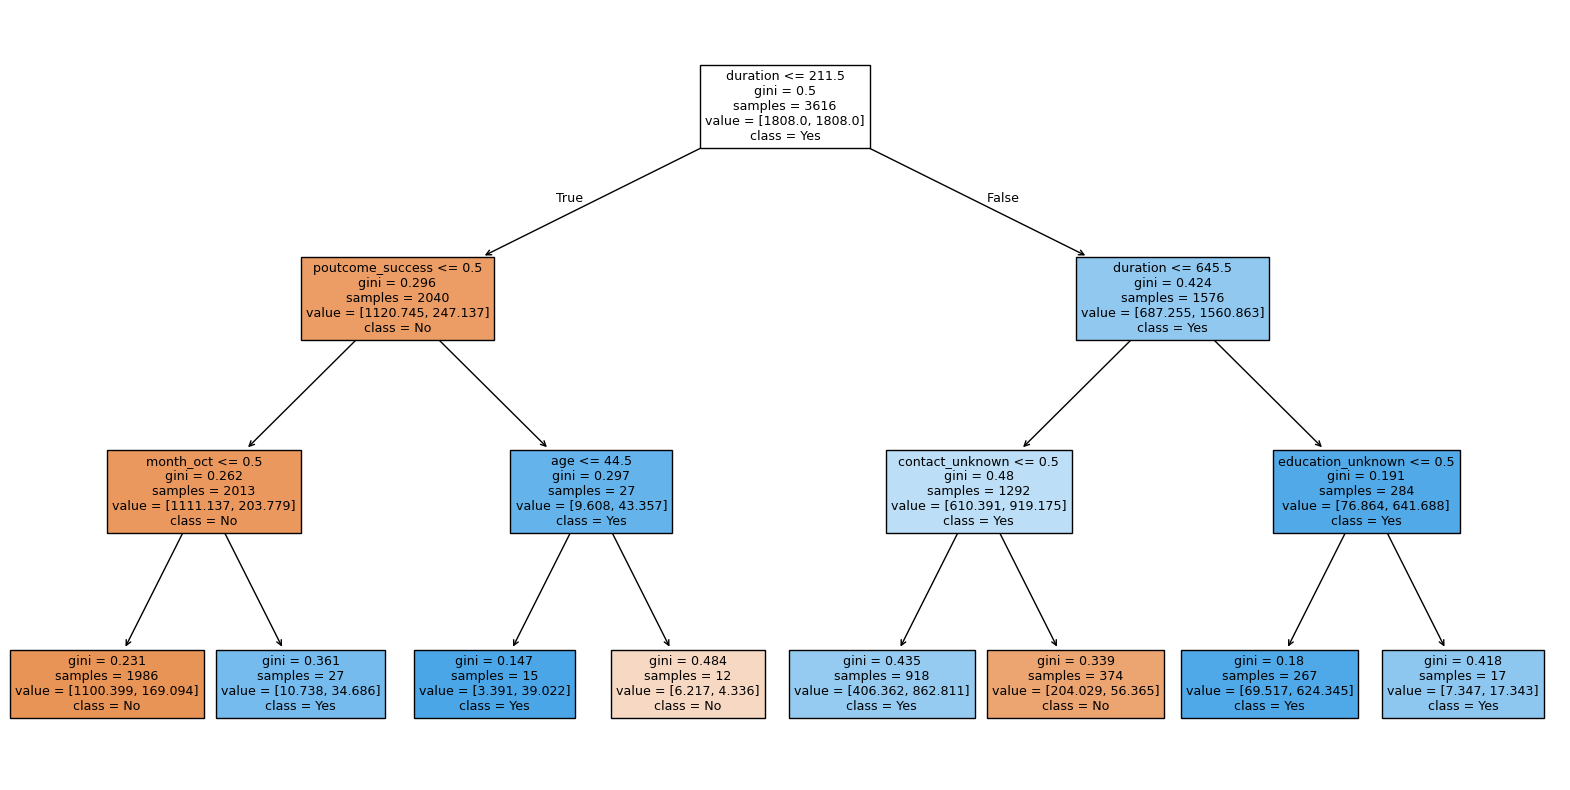

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_tree, filled=True, feature_names=x.columns, class_names=['No', 'Yes'], max_depth=3)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, \
average_precision_score
import matplotlib.pyplot as plt

In [ ]:
y_proba = best_tree.predict_proba(x_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)


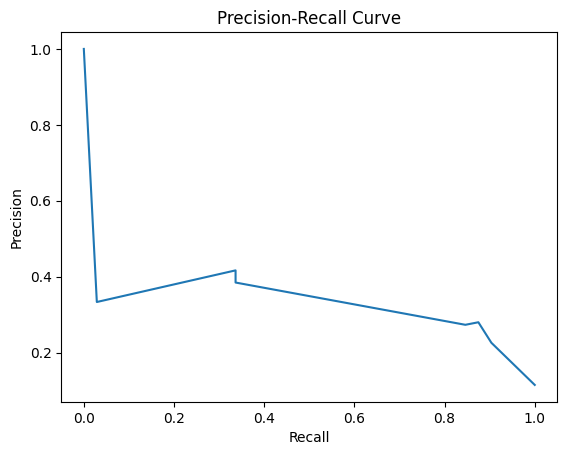

In [ ]:
plt.figure()
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.show()